This example shows a low-pass RC Filter.


In [ ]:


import math
import numpy as np
import matplotlib.pyplot as plt


import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()


from PySpice.Plot.BodeDiagram import bode_diagram
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *




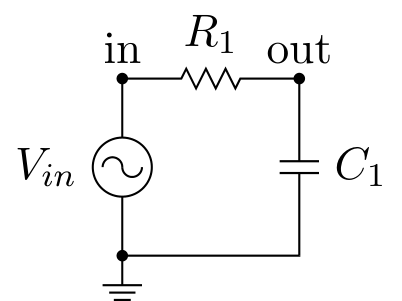

In [ ]:

circuit = Circuit('Low-Pass RC Filter')

circuit.SinusoidalVoltageSource('input', 'in', circuit.gnd, amplitude=1@u_V)
R1 = circuit.R(1, 'in', 'out', 1@u_kΩ)
C1 = circuit.C(1, 'out', circuit.gnd, 0.1@u_uF)



2026-07-04 22:27:35,129 - PySpice.Spice.Netlist.Node - Netlist.WARNING - Node name 'in' is a Python keyword


The break frequency is given by $f_c = \frac{1}{2 \pi R C}$


In [ ]:

break_frequency = 1 / (2 * math.pi * float(R1.resistance * C1.capacitance))
print("Break frequency = {:.1f} Hz".format(break_frequency))


Break frequency = 1591.5 Hz


In [ ]:

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.ac(start_frequency=1@u_Hz, stop_frequency=1@u_MHz, number_of_points=10,  variation='dec')
# print(analysis.out)



2026-07-04 22:27:47,358 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library C:\Program couldn't be loaded!
2026-07-04 22:27:47,359 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library Files\Python314\Lib\site-packages\PySpice\Spice\NgSpice\Spice64_dll\lib\ngspice/spice2poly.cm couldn't be loaded!
2026-07-04 22:27:47,360 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library C:\Program couldn't be loaded!
2026-07-04 22:27:47,361 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library Files\Python314\Lib\site-packages\PySpice\Spice\NgSpice\Spice64_dll\lib\ngspice/analog.cm couldn't be loaded!
2026-07-04 22:27:47,362 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library C:\Program couldn't be loaded!
2026-07-04 22:27:47,363 - PySpice.Spice.NgSpice.Shared.NgSpiceShared - Shared.ERROR - Error: Library Files\Python314\Lib\site-packages\PySpice\Spice\NgSpice\Spice64_dll\lib\ngspi

We plot the Bode diagram.


2026-07-04 22:27:54,101 - PySpice.Probe.WaveForm.WaveForm - Unit.WARNING - Should be unit less
2026-07-04 22:27:54,108 - PySpice.Probe.WaveForm.WaveForm - Unit.WARNING - Should be unit less


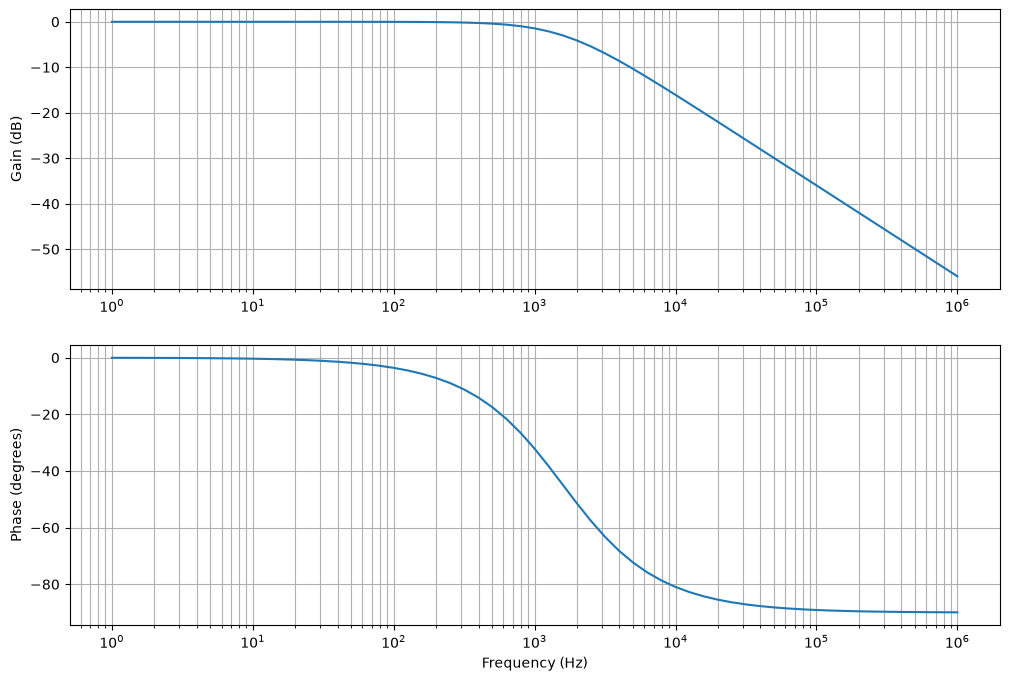

In [ ]:

fig, ax = plt.subplots(2, 1, figsize=(12,8))

# Gain
ax[0].semilogx(
    analysis.frequency,
    20*np.log10(np.abs(analysis.out)),
    base=10
)
ax[0].set_ylabel("Gain (dB)")
ax[0].grid(True, which="both")

# Phase
ax[1].semilogx(
    analysis.frequency,
    np.angle(analysis.out, deg=True),
    base=10
)
ax[1].set_ylabel("Phase (degrees)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].grid(True, which="both")

plt.show()
